# Student Dropout Early-Warning Analytics — Exploratory Data Analysis


## Project Goal
Build an early-warning model that predicts which students are at risk of dropping out, using only information available early in their academic journey (demographics, prior education, first-semester performance). The goal is to support timely intervention by student success teams.

## Dataset
**Source:** UCI Machine Learning Repository — *Predict Students' Dropout and Academic Success* (Realinho et al., 2021)  
**Records:** ~4,400 students from a higher education institution  
**Features:** 36 (demographics, socioeconomic factors, prior academics, semester grades)  
**Target:** Dropout / Enrolled / Graduate — for this analysis, reframed as binary (Dropout vs Not Dropout) for an early-warning use case  

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13

## 2. Load the Data

In [21]:
dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
print(f'Shape: {df.shape}')
df.head()

Shape: (4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [22]:
df.to_csv('data/raw_students.csv', index=False)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [24]:
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — dataset is complete.')

Columns with missing values:
None — dataset is complete.


In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


\
The original target has three classes (Dropout / Enrolled / Graduate). For an early-warning use case, we reframe as binary:
- **1 = Dropout** (the population we want to flag for intervention)
- **0 = Not Dropout** (Enrolled or Graduate)

This framing matches how real institutional early-warning systems are deployed, the system flags risk, the human decides what to do.

In [26]:
target_col = y.columns[0]
print(df[target_col].value_counts())
print()
print('Proportions:')
print(df[target_col].value_counts(normalize=True).round(3))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Proportions:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


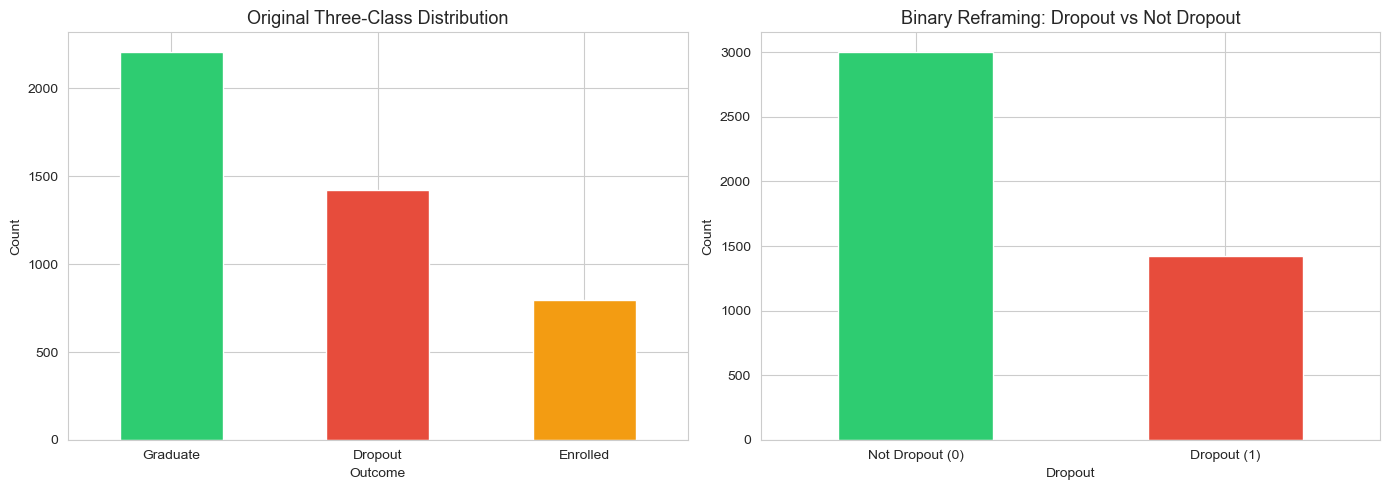


Overall dropout rate: 32.1%


In [27]:
df['Dropout'] = (df[target_col] == 'Dropout').astype(int)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Original Three-Class Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Dropout'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Binary Reframing: Dropout vs Not Dropout')
axes[1].set_xlabel('Dropout')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Not Dropout (0)', 'Dropout (1)'], rotation=0)
plt.tight_layout()
plt.show()

dropout_rate = df['Dropout'].mean()
print(f'\nOverall dropout rate: {dropout_rate:.1%}')



Looking at how dropout rates vary across demographic groups.

In [28]:
def plot_dropout_by_category(df, col, title=None, top_n=None):
    grouped = df.groupby(col)['Dropout'].agg(['mean', 'count']).reset_index()
    grouped = grouped[grouped['count'] >= 30]  # filter sparse categories
    grouped = grouped.sort_values('mean', ascending=False)
    if top_n:
        grouped = grouped.head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(grouped) * 0.4)))
    ax.barh(grouped[col].astype(str), grouped['mean'], color='#e74c3c', alpha=0.8)
    ax.axvline(df['Dropout'].mean(), color='black', linestyle='--', label=f'Overall rate ({df["Dropout"].mean():.1%})')
    ax.set_xlabel('Dropout Rate')
    ax.set_title(title or f'Dropout Rate by {col}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return grouped

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_2121/2296065874.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(col)['Dropout'].agg(['mean', 'count']).reset_index()


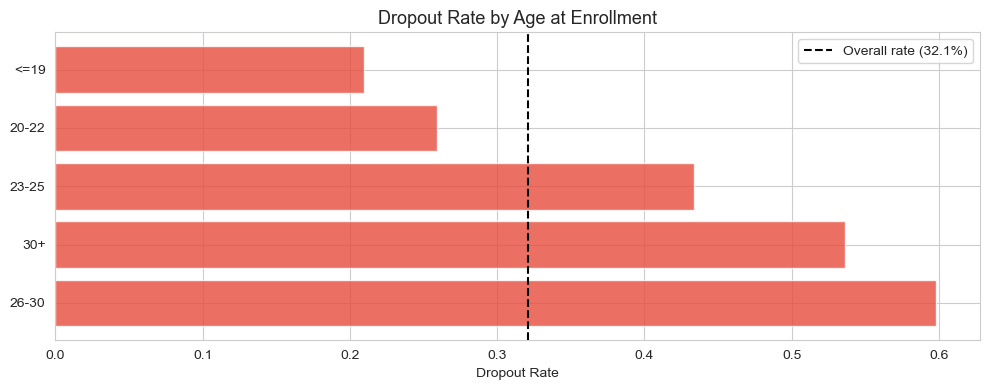

,Age_bucket,mean,count
3,26-30,0.597911,383
4,30+,0.536254,662
2,23-25,0.433735,332
1,20-22,0.259361,1095
0,<=19,0.209529,1952


In [29]:
df['Age_bucket'] = pd.cut(df['Age at enrollment'], 
                          bins=[0, 19, 22, 25, 30, 100],
                          labels=['<=19', '20-22', '23-25', '26-30', '30+'])
plot_dropout_by_category(df, 'Age_bucket', 'Dropout Rate by Age at Enrollment')

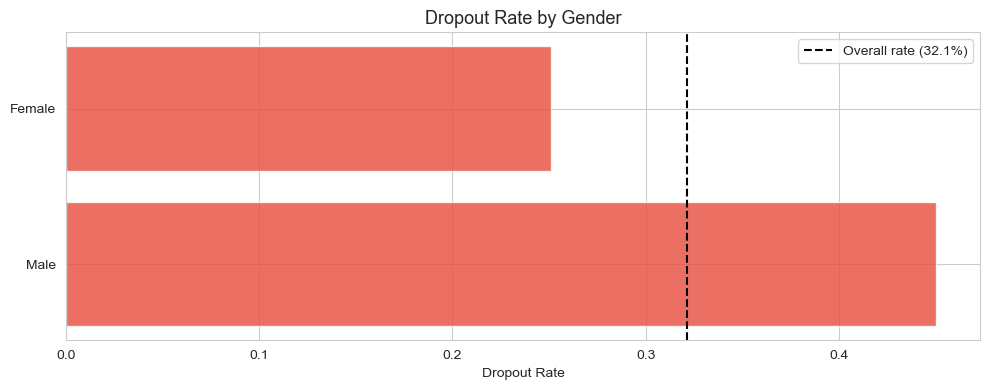

,Gender_label,mean,count
1,Male,0.450514,1556
0,Female,0.251046,2868


In [30]:

df['Gender_label'] = df['Gender'].map({0: 'Female', 1: 'Male'})
plot_dropout_by_category(df, 'Gender_label', 'Dropout Rate by Gender')

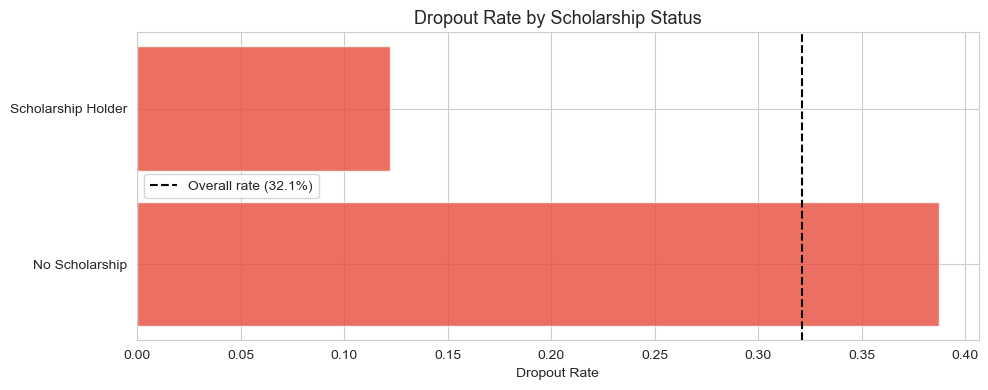

,Scholarship_label,mean,count
0,No Scholarship,0.387068,3325
1,Scholarship Holder,0.121929,1099


In [31]:

df['Scholarship_label'] = df['Scholarship holder'].map({0: 'No Scholarship', 1: 'Scholarship Holder'})
plot_dropout_by_category(df, 'Scholarship_label', 'Dropout Rate by Scholarship Status')

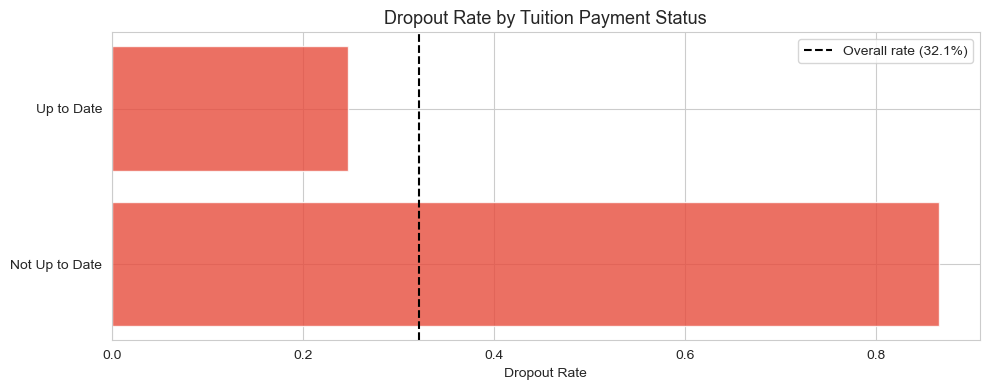

,Tuition_label,mean,count
0,Not Up to Date,0.865530,528
1,Up to Date,0.247433,3896


In [32]:

df['Tuition_label'] = df['Tuition fees up to date'].map({0: 'Not Up to Date', 1: 'Up to Date'})
plot_dropout_by_category(df, 'Tuition_label', 'Dropout Rate by Tuition Payment Status')



First and second semester academic performance is typically the strongest predictor of dropout.

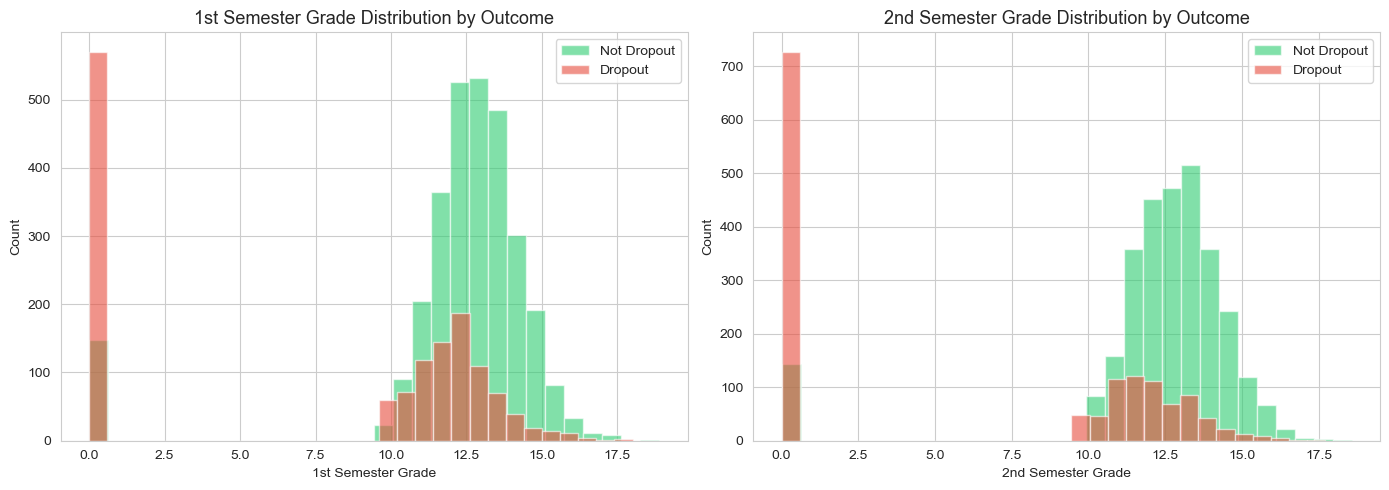

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for outcome, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    subset = df[df['Dropout'] == outcome]['Curricular units 1st sem (grade)']
    label = 'Not Dropout' if outcome == 0 else 'Dropout'
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('1st Semester Grade')
axes[0].set_ylabel('Count')
axes[0].set_title('1st Semester Grade Distribution by Outcome')
axes[0].legend()

for outcome, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    subset = df[df['Dropout'] == outcome]['Curricular units 2nd sem (grade)']
    label = 'Not Dropout' if outcome == 0 else 'Dropout'
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_xlabel('2nd Semester Grade')
axes[1].set_ylabel('Count')
axes[1].set_title('2nd Semester Grade Distribution by Outcome')
axes[1].legend()
plt.tight_layout()
plt.show()

/var/folders/hp/vhxv6c0n2mjfq0psxp51ndg00000gn/T/ipykernel_2121/2296065874.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(col)['Dropout'].agg(['mean', 'count']).reset_index()


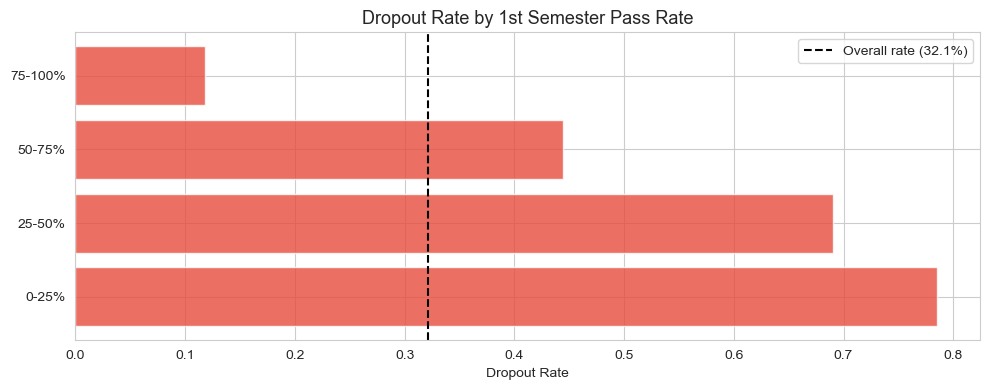

,Sem1_pass_bucket,mean,count
0,0-25%,0.785124,847
1,25-50%,0.690476,294
2,50-75%,0.444008,509
3,75-100%,0.117880,2774


In [34]:
df['Sem1_pass_rate'] = np.where(
    df['Curricular units 1st sem (enrolled)'] > 0,
    df['Curricular units 1st sem (approved)'] / df['Curricular units 1st sem (enrolled)'],
    0
)
df['Sem2_pass_rate'] = np.where(
    df['Curricular units 2nd sem (enrolled)'] > 0,
    df['Curricular units 2nd sem (approved)'] / df['Curricular units 2nd sem (enrolled)'],
    0
)

df['Sem1_pass_bucket'] = pd.cut(df['Sem1_pass_rate'], 
                                bins=[-0.01, 0.25, 0.5, 0.75, 1.01],
                                labels=['0-25%', '25-50%', '50-75%', '75-100%'])
plot_dropout_by_category(df, 'Sem1_pass_bucket', 'Dropout Rate by 1st Semester Pass Rate')

Correlations with Dropout

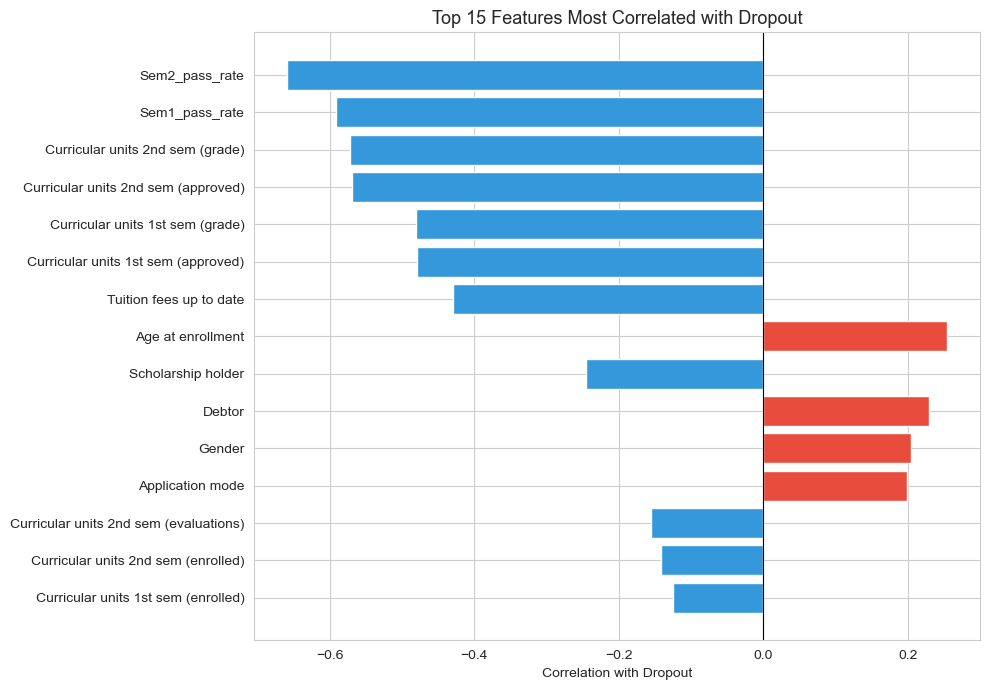


Top positive correlations (predict dropout):
Age at enrollment    0.254
Debtor               0.229
Gender               0.204
Application mode     0.198
Marital Status       0.094
Name: Dropout, dtype: float64

Top negative correlations (predict success):
Sem2_pass_rate                        -0.659
Sem1_pass_rate                        -0.591
Curricular units 2nd sem (grade)      -0.572
Curricular units 2nd sem (approved)   -0.570
Curricular units 1st sem (grade)      -0.481
Name: Dropout, dtype: float64


In [35]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['Dropout'].drop('Dropout').sort_values(key=abs, ascending=False)
top_corr = corr.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Dropout')
ax.set_title('Top 15 Features Most Correlated with Dropout')
plt.tight_layout()
plt.show()

print('\nTop positive correlations (predict dropout):')
print(corr[corr > 0].head(5).round(3))
print('\nTop negative correlations (predict success):')
print(corr[corr < 0].head(5).round(3))

In [36]:
model_df = df.drop(columns=['Age_bucket', 'Gender_label', 'Scholarship_label', 
                             'Tuition_label', 'Sem1_pass_bucket'])
model_df.to_csv('data/students_cleaned.csv', index=False)
print(f'Saved {len(model_df)} rows × {len(model_df.columns)} columns to data/students_cleaned.csv')

Saved 4424 rows × 40 columns to data/students_cleaned.csv
